# Perceptron algorithm

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

## Perceptron algorithm

Labels `y` must be in `{-1, +1}`.

In [14]:
def perceptron(X, y, epochs=1000):
    X = np.column_stack([X, np.ones(len(X))])  # append a constant feature for the bias
    w = np.zeros(X.shape[1])
    for i in range(epochs):
        errors = 0
        for xi, yi in zip(X, y):
            # must be <=, not <: w starts at zero, so every point sits exactly
            # on the boundary and nothing would ever count as a mistake
            if yi * (xi @ w) <= 0:
                w += yi * xi
                errors += 1
        if errors == 0:
            print(f"converged after {i + 1} epochs")
            return w
    print(f"did not converge after {epochs} epochs")
    return w


def decision_function(X, w):
    X = np.column_stack([X, np.ones(len(X))])
    return X @ w


def predict(X, w):
    return np.sign(decision_function(X, w))


def plot_2d(X, y, w=None, title=""):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="+1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label="-1")
    if w is not None:
        x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
        y_line = -(w[0] * x_line + w[-1]) / w[1]
        plt.plot(x_line, y_line, "k-", label="decision boundary")
    plt.legend()
    plt.title(title)
    plt.show()

## 1. Separable data in 2D

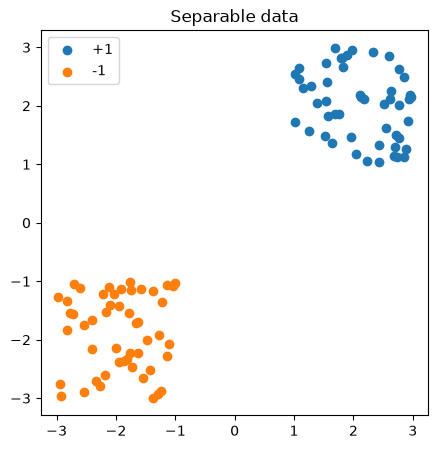

In [15]:
# two boxes of points, [-3,-1]^2 and [1,3]^2, which cannot overlap for any seed
rng = np.random.default_rng(0)
X_sep = np.vstack([rng.uniform(-1, 1, (50, 2)) - 2, rng.uniform(-1, 1, (50, 2)) + 2])
y_sep = np.repeat([-1, 1], 50)

plot_2d(X_sep, y_sep, title="Separable data")

converged after 2 epochs


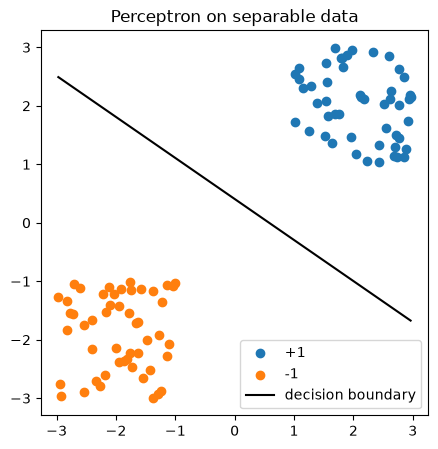

In [16]:
w = perceptron(X_sep, y_sep)
assert (predict(X_sep, w) == y_sep).all()
plot_2d(X_sep, y_sep, w, "Perceptron on separable data")

## 2. Non-separable data

A ring of points inside a ring of points can't be split by any straight line, so the perceptron never converges and ends up with a fairly arbitrary line.

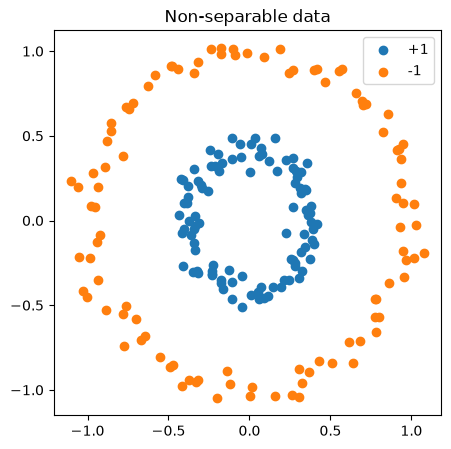

In [17]:
X_circ, y_circ = make_circles(n_samples=200, noise=0.05, factor=0.4, random_state=0)
y_circ = np.where(y_circ == 0, -1, 1)

plot_2d(X_circ, y_circ, title="Non-separable data")

did not converge after 1000 epochs


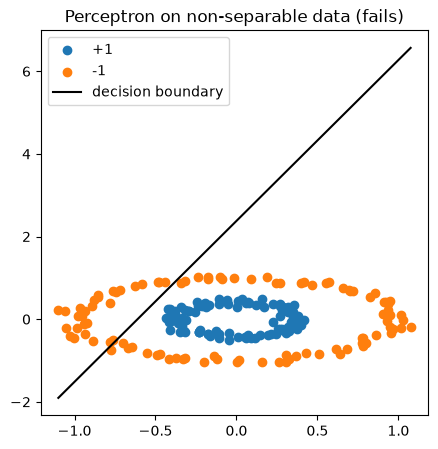

In [18]:
w = perceptron(X_circ, y_circ)
plot_2d(X_circ, y_circ, w, "Perceptron on non-separable data (fails)")

## 3. Lift into higher dimension with nonlinear features

Add $x_1^2$, $x_2^2$, and $x_1 x_2$ as extra features. In this 5D feature space the two rings become linearly separable (e.g. by $x_1^2 + x_2^2$, the squared radius).

In [19]:
def phi(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1, x2, x1**2, x2**2, x1 * x2])


X_feat = phi(X_circ)
w_nl = perceptron(X_feat, y_circ)

accuracy = (predict(X_feat, w_nl) == y_circ).mean()
print(f"accuracy with nonlinear features: {accuracy:.2f}")

converged after 2 epochs
accuracy with nonlinear features: 1.00


## 4. Plot the nonlinear decision boundary back in the original 2D space

The boundary is linear in the 5D feature space, but curved (circular) when mapped back to $(x_1, x_2)$.

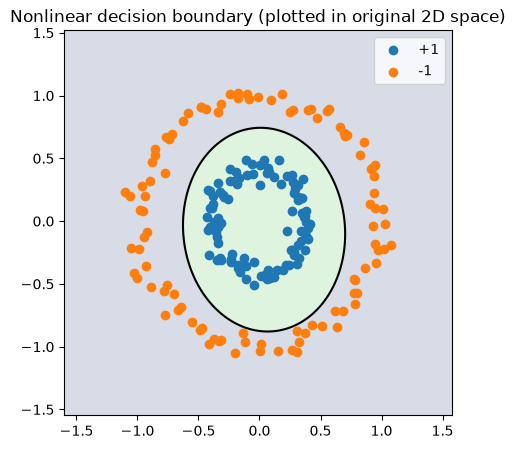

In [20]:
xx, yy = np.meshgrid(
    np.linspace(X_circ[:, 0].min() - 0.5, X_circ[:, 0].max() + 0.5, 300),
    np.linspace(X_circ[:, 1].min() - 0.5, X_circ[:, 1].max() + 0.5, 300),
)
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = decision_function(phi(grid), w_nl).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, zz > 0, alpha=0.2, levels=1)
plt.contour(xx, yy, zz, levels=[0], colors="k")
plt.scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], label="+1")
plt.scatter(X_circ[y_circ == -1, 0], X_circ[y_circ == -1, 1], label="-1")
plt.legend()
plt.title("Nonlinear decision boundary (plotted in original 2D space)")
plt.show()